# LLR Comparison: Base ESM2 vs LoRA-Finetuned (per-pfam)

Loads the LoRA delta weights produced by `ESM_domainome_ft_pfam.ipynb` for each pfam,
recomputes per-domain LLR matrices with both the un-finetuned base model and the
finetuned model for that pfam, and uploads one gzipped pickle per pfam to GCS:
`{domain_id: {sequence, seq_offset, base_llr, ft_llr, delta_llr, ...}}`.

Output paths mirror the training run, i.e. one
`llr_comparison_all.pkl.gz` per pfam under
`gs://{bucket}/{prefix}/global_finetune/{pfam_id}/`.


In [4]:
# !pip install -q -U "torchao>=0.16.0"

In [5]:
import os
import io
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import torch

from dotenv import load_dotenv
from tqdm import tqdm

from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.sparse import csr_matrix, issparse


In [7]:
# ── Constants (must match training run) ──────────────────────────────────────

AA_ORDER         = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                    'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
FITNESS_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
MODEL_NAME       = "facebook/esm2_t33_650M_UR50D"
MAX_LEN          = 1022
LORA_DROPOUT     = 0.1

# ── Local + GCS layout (must match training run) ─────────────────────────────

# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "plm-study-484223-e1c13b49d132.json"

OUTPUT_DIR     = "finetuned_models_v2"
RUN_ID_PREFIX  = "global_finetune"   # matches training notebook's run_id = f"{RUN_ID_PREFIX}/{pfam_id}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

GCS_PROJECT           = "plm-study-484223"
GCS_BUCKET            = "domainome-data"
GCS_DOMAIN_DATA_BLOB  = "ESM2/dict_fitness.pkl.gz"
GCS_FULL_PROTEIN_BLOB = "ESM2/dict_domainome_uniprot_new.pkl.gz"
GCS_OUTPUT_PREFIX     = "ESM2/ft_per_pfam/"   # must end with /

LLR_OUTPUT_NAME = "llr_comparison_all.pkl.gz"


def pfam_paths(pfam_id):
    """Resolve all per-pfam local + GCS paths from a pfam id."""
    run_id  = f"{RUN_ID_PREFIX}/{pfam_id}"
    run_dir = os.path.join(OUTPUT_DIR, run_id)
    # os.makedirs(run_dir, exist_ok=True)
    return {
        "run_id":        run_id,
        "run_dir":       run_dir,
        "metadata_local": os.path.join(run_dir, "metadata.json"),
        "lora_local":    os.path.join(run_dir, "best_model_lora.pth"),
        "llr_local":     os.path.join(run_dir, LLR_OUTPUT_NAME),
        "gcs_metadata":  f"{GCS_OUTPUT_PREFIX}{run_id}/metadata.json",
        "gcs_lora":      f"{GCS_OUTPUT_PREFIX}{run_id}/best_model_lora.pth",
        "gcs_llr":       f"{GCS_OUTPUT_PREFIX}{run_id}/{LLR_OUTPUT_NAME}",
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [8]:
# ── GCS Helpers ──────────────────────────────────────────────────────────────
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] ='plm-study-484223-e1c13b49d132.json'

# _gcs_client = storage.Client(project=GCS_PROJECT) if GCS_PROJECT else storage.Client()
_gcs_client = storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)


def gcs_download_pickle_gz(blob):
    data = blob.download_as_bytes()
    with gzip.GzipFile(fileobj=io.BytesIO(data), mode="rb") as gz:
        return pickle.load(gz)


def gcs_download_to_file(blob_path, local_path):
    blob = _gcs_bucket.blob(blob_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    return local_path


def gcs_upload_file(blob_path, local_path, content_type="application/octet-stream"):
    blob = _gcs_bucket.blob(blob_path)
    blob.upload_from_filename(local_path, content_type=content_type)

In [9]:
# ── Helpers (mirrored from training notebook) ────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def fitness_matrix_to_rows(fitness, dom_seq, position_offset=0):
    rows = []
    for i, wt_aa in enumerate(dom_seq):
        if i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            if mut_aa == wt_aa:
                continue
            rows.append({
                "position":           position_offset + i + 1,
                "wt_aa":              wt_aa,
                "mut_aa":             mut_aa,
                "normalized_fitness": fval,
            })
    return rows


def build_lora_model(lora_r, lora_alpha):
    """Rebuild the exact ESM2 + LoRA architecture used during training."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    return model


def recover_domains_from_metadata(metadata):
    """Pull per-domain {sequence, seq_offset, ...} out of a pfam's metadata.json.

    The training notebook writes a `domains` block per pfam that already
    contains the truncated input sequence and seq_offset used at training time,
    so we just normalize the fields here.
    """
    out = {}
    meta_domains = metadata.get("domains") or {}
    for domain_id, dinfo in meta_domains.items():
        if not isinstance(dinfo, dict) or "sequence" not in dinfo:
            continue
        out[domain_id] = {
            "uniprot_id":           dinfo.get("uniprot_id"),
            "sequence":             dinfo["sequence"],
            "seq_offset":           int(dinfo.get("seq_offset", 0)),
            "used_full_protein":    bool(dinfo.get("used_full_protein", False)),
            "dom_start_in_protein": int(dinfo.get("dom_start_in_protein", 0)),
        }
    return out

def gcs_download_bytes(gcs_path, bucket_name=GCS_BUCKET):
    """
    Download a GCS object directly into memory as bytes.
    """
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)

    return blob.download_as_bytes()


def gcs_upload_bytes(
    gcs_path,
    data_bytes,
    bucket_name=GCS_BUCKET,
    content_type=None
):
    """
    Upload raw bytes directly to GCS from memory.
    """
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)

    blob.upload_from_file(
        io.BytesIO(data_bytes),
        size=len(data_bytes),
        content_type=content_type
    )

In [10]:
# ── Discover pfams from GCS ──────────────────────────────────────────────────
#
# The training notebook writes one directory per pfam under
# `GCS_OUTPUT_PREFIX{RUN_ID_PREFIX}/{pfam_id}/` (each containing a
# `metadata.json` + `best_model_lora.pth`). We list those blobs and recover
# the set of pfam ids that have a finetuned model available.

_run_prefix = f"{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/"

PFAM_IDS = sorted({
    blob.name[len(_run_prefix):].split("/", 1)[0]
    for blob in _gcs_client.list_blobs(GCS_BUCKET, prefix=_run_prefix)
    if blob.name.endswith("/metadata.json")
})

print(f"Found {len(PFAM_IDS)} pfams under gs://{GCS_BUCKET}/{_run_prefix}")
print(PFAM_IDS[:10], "..." if len(PFAM_IDS) > 10 else "")


Found 126 pfams under gs://domainome-data/ESM2/ft_per_pfam/global_finetune/
['PF00010', 'PF00013', 'PF00018', 'PF00030', 'PF00035', 'PF00046', 'PF00096', 'PF00105', 'PF00130', 'PF00157'] ...


## Reload a pfam's comparison dict

```python
import gzip, io, pickle, pandas as pd
from google.cloud import storage

pfam_id = "PF00001"  # pick one

blob = storage.Client().bucket("<bucket>").blob(
    f"<prefix>/global_finetune/{pfam_id}/llr_comparison_all.pkl.gz"
)
with gzip.open(io.BytesIO(blob.download_as_bytes()), "rb") as gz:
    payload = pickle.load(gz)

entry    = payload["domains"]["<domain_id>"]
base_df  = pd.DataFrame(entry["base_llr"],  index=entry["aa_order"], columns=entry["positions"])
ft_df    = pd.DataFrame(entry["ft_llr"],    index=entry["aa_order"], columns=entry["positions"])
delta_df = pd.DataFrame(entry["delta_llr"], index=entry["aa_order"], columns=entry["positions"])
```


In [2]:
# pip install -U numpy

In [3]:
# import numpy as np
# print(np.__version__)
# 1.26.4

In [11]:
# ── Reload per-pfam payloads (skip recompute) ────────────────────────────────
#
# For each pfam under PFAM_IDS, prefer the local pickle and fall back to
# downloading from GCS. Populates `pfam_payloads` so the Spearman + plotting
# cells below run without recomputing LLRs.

pfam_payloads = {}

for pfam_id in PFAM_IDS:
    paths = pfam_paths(pfam_id)
    if not os.path.exists(paths["llr_local"]):
        try:
            gcs_download_to_file(paths["gcs_llr"], paths["llr_local"])
        except Exception as exc:
            print(f"[{pfam_id}] download failed: {exc}")
            continue
    with gzip.open(paths["llr_local"], "rb") as gz:
        pfam_payloads[pfam_id] = pickle.load(gz)

print(f"Loaded payloads for {len(pfam_payloads)} pfams")
if pfam_payloads:
    sample_pfam = next(iter(pfam_payloads))
    sample_payload = pfam_payloads[sample_pfam]
    sample_id   = next(iter(sample_payload["domains"]))
    sample      = sample_payload["domains"][sample_id]
    print(f"Sample pfam={sample_pfam} domain={sample_id} "
          f"seq_len={len(sample['sequence'])} "
          f"base_llr={sample['base_llr'].shape} "
          f"ft_llr={sample['ft_llr'].shape}")


KeyboardInterrupt: 

In [12]:
# ── Build a single DataFrame with all values from every pfam's ──────────────
# ── llr_comparison_all.pkl.gz on GCS (streamed, no local files) ──────────────
#
# For each pfam folder under `gs://{GCS_BUCKET}/{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/`,
# stream `llr_comparison_all.pkl.gz` straight from GCS into memory, unpickle
# it, flatten `payload["domains"]` into one row per domain, and concatenate
# every pfam into a single `llr_df` DataFrame. Matrix/array fields
# (`base_llr`, `ft_llr`, `delta_llr`, ...) are kept as numpy arrays in object
# columns; any top-level payload metadata (everything in the payload except
# `"domains"`) is prefixed with `pfam_` and broadcast across that pfam's rows.

_rows = []
_missing = []

for pfam_id in tqdm(PFAM_IDS, desc="Loading llr_comparison_all.pkl.gz"):
    gcs_blob_path = f"{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/{pfam_id}/{LLR_OUTPUT_NAME}"
    try:
        payload = gcs_download_pickle_gz(_gcs_bucket.blob(gcs_blob_path))
    except Exception as exc:
        _missing.append((pfam_id, str(exc)))
        continue

    pfam_meta = {f"pfam_{k}": v for k, v in payload.items() if k != "domains"}

    for domain_id, entry in payload.get("domains", {}).items():
        row = {"pfam_id": pfam_id, "domain_id": domain_id}
        row.update(pfam_meta)
        row.update(entry)
        _rows.append(row)

llr_df = pd.DataFrame(_rows)

print(f"Loaded {len(llr_df)} domain rows across {llr_df['pfam_id'].nunique()} pfams")
if _missing:
    print(f"Skipped {len(_missing)} pfams (first 5): {_missing[:5]}")
print("Columns:", list(llr_df.columns))
llr_df.head()


Loading llr_comparison_all.pkl.gz: 100%|██████████| 126/126 [12:01<00:00,  5.73s/it]


Loaded 36018 domain rows across 69 pfams
Skipped 57 pfams (first 5): [('PF02359', "404 GET https://storage.googleapis.com/download/storage/v1/b/domainome-data/o/ESM2%2Fft_per_pfam%2Fglobal_finetune%2FPF02359%2Fllr_comparison_all.pkl.gz?alt=media: No such object: domainome-data/ESM2/ft_per_pfam/global_finetune/PF02359/llr_comparison_all.pkl.gz: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>, <HTTPStatus.PARTIAL_CONTENT: 206>)"), ('PF02376', "404 GET https://storage.googleapis.com/download/storage/v1/b/domainome-data/o/ESM2%2Fft_per_pfam%2Fglobal_finetune%2FPF02376%2Fllr_comparison_all.pkl.gz?alt=media: No such object: domainome-data/ESM2/ft_per_pfam/global_finetune/PF02376/llr_comparison_all.pkl.gz: ('Request failed with status code', 404, 'Expected one of', <HTTPStatus.OK: 200>, <HTTPStatus.PARTIAL_CONTENT: 206>)"), ('PF02817', "404 GET https://storage.googleapis.com/download/storage/v1/b/domainome-data/o/ESM2%2Fft_per_pfam%2Fglobal_finetune%2FPF02817%

,pfam_id,domain_id,pfam_run_id,pfam_pfam_id,pfam_model_name,pfam_best_config,pfam_aa_order,pfam_n_domains,pfam_n_train_domains,uniprot_id,sequence,seq_offset,used_full_protein,dom_start_in_protein,aa_order,positions,base_llr,ft_llr,delta_llr,in_pfam_train
0,PF00010,A0A2R8Y422_PF00240_2,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0A2R8Y422,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[Q 1, I 2, F 3, V 4, K 5, T 6, L 7, M 8, G 9, ...","[[-3.5157275, -5.9415855, -8.149918, -5.678594...","[[-4.2675524, -4.7696867, -4.3836045, -4.11129...","[[-0.75182486, 1.1718988, 3.766313, 1.5672965,...",False
1,PF00010,A0PJY2_PF00096_289,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0PJY2,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,0,True,288,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, D 2, S 3, S 4, C 5, H 6, N 7, A 8, T 9, ...","[[-7.877233, -3.0762224, -3.9222503, -3.706128...","[[-7.9733877, -2.7160609, -3.8156652, -3.67532...","[[-0.09615469, 0.36016154, 0.106585026, 0.0308...",False
2,PF00010,A1X283_PF00018_155,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,MPPRRSIVEVKVLDVQKRRVPNKHYVYIIRVTWSSGSTEAIYRRYS...,0,True,154,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False
3,PF00010,A1X283_PF00018_222,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,MPPRRSIVEVKVLDVQKRRVPNKHYVYIIRVTWSSGSTEAIYRRYS...,0,True,221,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False
4,PF00010,A2RRE5_PF01846_267,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A2RRE5,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[S 1, Q 2, Q 3, I 4, A 5, T 6, A 7, K 8, D 9, ...","[[-2.97742, -3.6223297, -3.273647, -3.0311143,...","[[-2.7942326, -2.8969717, -2.461637, -2.973482...","[[0.18318748, 0.725358, 0.81201005, 0.05763173...",False


In [16]:
llr_df.rename(columns={'pfam_id':'model_pfam'},inplace=True)

In [17]:
llr_df['input_pfam'] = llr_df['domain_id'].str.split("_").str[1]

In [18]:
llr_df.head()

,model_pfam,domain_id,pfam_run_id,pfam_pfam_id,pfam_model_name,pfam_best_config,pfam_aa_order,pfam_n_domains,pfam_n_train_domains,uniprot_id,...,seq_offset,used_full_protein,dom_start_in_protein,aa_order,positions,base_llr,ft_llr,delta_llr,in_pfam_train,input_pfam
0,PF00010,A0A2R8Y422_PF00240_2,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0A2R8Y422,...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[Q 1, I 2, F 3, V 4, K 5, T 6, L 7, M 8, G 9, ...","[[-3.5157275, -5.9415855, -8.149918, -5.678594...","[[-4.2675524, -4.7696867, -4.3836045, -4.11129...","[[-0.75182486, 1.1718988, 3.766313, 1.5672965,...",False,PF00240
1,PF00010,A0PJY2_PF00096_289,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A0PJY2,...,0,True,288,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, D 2, S 3, S 4, C 5, H 6, N 7, A 8, T 9, ...","[[-7.877233, -3.0762224, -3.9222503, -3.706128...","[[-7.9733877, -2.7160609, -3.8156652, -3.67532...","[[-0.09615469, 0.36016154, 0.106585026, 0.0308...",False,PF00096
2,PF00010,A1X283_PF00018_155,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,...,0,True,154,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False,PF00018
3,PF00010,A1X283_PF00018_222,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A1X283,...,0,True,221,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[M 1, P 2, P 3, R 4, R 5, S 6, I 7, V 8, E 9, ...","[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False,PF00018
4,PF00010,A2RRE5_PF01846_267,global_finetune/PF00010,PF00010,facebook/esm2_t33_650M_UR50D,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}","[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...",522,2,A2RRE5,...,0,False,0,"[L, A, G, V, S, E, R, T, I, D, P, K, Q, N, F, ...","[S 1, Q 2, Q 3, I 4, A 5, T 6, A 7, K 8, D 9, ...","[[-2.97742, -3.6223297, -3.273647, -3.0311143,...","[[-2.7942326, -2.8969717, -2.461637, -2.973482...","[[0.18318748, 0.725358, 0.81201005, 0.05763173...",False,PF01846


In [19]:
llr_df.columns

Index(['model_pfam', 'domain_id', 'pfam_run_id', 'pfam_pfam_id',
       'pfam_model_name', 'pfam_best_config', 'pfam_aa_order',
       'pfam_n_domains', 'pfam_n_train_domains', 'uniprot_id', 'sequence',
       'seq_offset', 'used_full_protein', 'dom_start_in_protein', 'aa_order',
       'positions', 'base_llr', 'ft_llr', 'delta_llr', 'in_pfam_train',
       'input_pfam'],
      dtype='object')

In [26]:
clean_llr_df = llr_df[['model_pfam', 'domain_id', 'input_pfam', 'base_llr', 'ft_llr', 'delta_llr', 'in_pfam_train', 'used_full_protein', 'sequence', 'pfam_best_config']]

In [28]:
clean_llr_df["n_input_pfam_per_model"] = (
    clean_llr_df.groupby(["model_pfam", "input_pfam"])["domain_id"]
      .transform("count")
)

In [29]:
clean_llr_df.head()

,model_pfam,domain_id,input_pfam,base_llr,ft_llr,delta_llr,in_pfam_train,used_full_protein,sequence,pfam_best_config,n_input_pfam_per_model
0,PF00010,A0A2R8Y422_PF00240_2,PF00240,"[[-3.5157275, -5.9415855, -8.149918, -5.678594...","[[-4.2675524, -4.7696867, -4.3836045, -4.11129...","[[-0.75182486, 1.1718988, 3.766313, 1.5672965,...",False,False,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}",1
1,PF00010,A0PJY2_PF00096_289,PF00096,"[[-7.877233, -3.0762224, -3.9222503, -3.706128...","[[-7.9733877, -2.7160609, -3.8156652, -3.67532...","[[-0.09615469, 0.36016154, 0.106585026, 0.0308...",False,True,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}",36
2,PF00010,A1X283_PF00018_155,PF00018,"[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False,True,MPPRRSIVEVKVLDVQKRRVPNKHYVYIIRVTWSSGSTEAIYRRYS...,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}",36
3,PF00010,A1X283_PF00018_222,PF00018,"[[-6.4155345, -4.8084373, -3.6606545, -4.35059...","[[-9.526212, -3.9824302, -3.6121767, -3.475053...","[[-3.1106772, 0.8260071, 0.048477888, 0.875539...",False,True,MPPRRSIVEVKVLDVQKRRVPNKHYVYIIRVTWSSGSTEAIYRRYS...,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}",36
4,PF00010,A2RRE5_PF01846_267,PF01846,"[[-2.97742, -3.6223297, -3.273647, -3.0311143,...","[[-2.7942326, -2.8969717, -2.461637, -2.973482...","[[0.18318748, 0.725358, 0.81201005, 0.05763173...",False,False,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...,"{'lr': 0.001, 'lora_r': 128, 'lora_alpha': 256}",12


In [8]:
# ── Spearman: fitness vs (base LLR, finetuned LLR) per domain × pfam ────────
#
# For every domain across every pfam in `pfam_payloads`, line up each measured
# (position, mut_aa) fitness value with the corresponding entry in the base and
# finetuned LLR matrices and compute Spearman ρ separately for base and ft.

from scipy.stats import spearmanr

try:
    fitness_dict
except NameError:
    print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
    fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
    print(f"Loaded {len(fitness_dict)} fitness entries")

aa_to_row = {aa: i for i, aa in enumerate(AA_ORDER)}

per_domain_rows = []
skipped_no_match = 0
skipped_too_few  = 0

for pfam_id, payload in tqdm(pfam_payloads.items(), desc="Pfams"):
    for domain_id, entry in payload["domains"].items():
        fd = fitness_dict.get(domain_id)
        if not isinstance(fd, dict):
            continue
        fitness = fd.get("fitness")
        dom_seq = fd.get("dom_seq")
        if fitness is None or dom_seq is None:
            continue

        sequence = entry["sequence"]
        base_llr = entry["base_llr"]
        ft_llr   = entry["ft_llr"]
        n_pos    = base_llr.shape[1]

        idx_in_seq = sequence.find(dom_seq)
        if idx_in_seq < 0:
            skipped_no_match += 1
            continue

        fits, base_vals, ft_vals = [], [], []
        for i, wt_aa in enumerate(dom_seq):
            col = idx_in_seq + i
            if col >= n_pos or i >= len(fitness):
                break
            row = fitness[i]
            for j, mut_aa in enumerate(FITNESS_AA_ORDER):
                if j >= len(row):
                    continue
                val = row[j]
                if val is None or mut_aa == wt_aa:
                    continue
                try:
                    fval = float(val)
                except (TypeError, ValueError):
                    continue
                if np.isnan(fval):
                    continue
                r = aa_to_row.get(mut_aa)
                if r is None:
                    continue
                fits.append(fval)
                base_vals.append(float(base_llr[r, col]))
                ft_vals.append(float(ft_llr[r, col]))

        if len(fits) < 10:
            skipped_too_few += 1
            continue

        fits      = np.asarray(fits)
        base_vals = np.asarray(base_vals)
        ft_vals   = np.asarray(ft_vals)

        rho_base, p_base = spearmanr(fits, base_vals)
        rho_ft,   p_ft   = spearmanr(fits, ft_vals)

        per_domain_rows.append({
            "pfam_id":    pfam_id,
            "domain_id":  domain_id,
            "uniprot_id": entry.get("uniprot_id"),
            "n":          int(len(fits)),
            "rho_base":   float(rho_base),
            "p_base":     float(p_base),
            "rho_ft":     float(rho_ft),
            "p_ft":       float(p_ft),
            "delta_rho":  float(rho_ft - rho_base),
        })

corr_df = pd.DataFrame(per_domain_rows).sort_values("delta_rho", ascending=False)

print(f"Computed Spearman for {len(corr_df)} domains "
      f"(skipped {skipped_no_match} no-match, {skipped_too_few} too-few)")
print(f"Mean ρ_base : {corr_df['rho_base'].mean():+.4f}   "
      f"median {corr_df['rho_base'].median():+.4f}")
print(f"Mean ρ_ft   : {corr_df['rho_ft'].mean():+.4f}   "
      f"median {corr_df['rho_ft'].median():+.4f}")
print(f"Mean Δρ     : {corr_df['delta_rho'].mean():+.4f}   "
      f"median {corr_df['delta_rho'].median():+.4f}")
print(f"Domains improved (Δρ > 0): "
      f"{(corr_df['delta_rho'] > 0).sum()} / {len(corr_df)} "
      f"({(corr_df['delta_rho'] > 0).mean()*100:.1f}%)")

corr_df.head(10)


Loading fitness dict from gs://domainome-data/ESM2/dict_fitness.pkl.gz
Loaded 522 fitness entries


Pfams: 0it [00:00, ?it/s]


KeyError: 'delta_rho'

In [ ]:
corr_df.sort_values("pfam_id").head(30)

,pfam_id,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho
0,PF00010,P50539_PF00010_70,P50539,939,0.271619,2.413463e-17,0.493691,7.603561e-59,0.222072
1,PF00010,Q05195_PF00010_58,Q05195,938,0.201825,4.452025e-10,0.510663,1.966802e-63,0.308838
3,PF00013,Q06787_PF00013_217,Q06787,1212,0.429986,1.027802e-55,0.460133,1.538933e-64,0.030147
2,PF00013,P61978_PF00013_385,P61978,1406,0.359444,3.920498e-44,0.415475,8.654241e-60,0.056032
10,PF00013,Q96I24_PF00013_75,Q96I24,1443,0.451784,1.704134e-73,0.655272,8.967053e-178,0.203488
4,PF00013,Q15365_PF00013_278,Q15365,1360,0.370118,2.092788e-45,0.695142,6.704938e-197,0.325024
9,PF00013,Q96AE4_PF00013_98,Q96AE4,1341,0.399393,1.614882e-52,0.594967,3.313053e-129,0.195574
8,PF00013,Q96AE4_PF00013_184,Q96AE4,1406,0.483132,4.016785e-83,0.642705,1.168421e-164,0.159573
7,PF00013,Q92945_PF00013_142,Q92945,1387,0.412251,4.940292e-58,0.653580,8.915567e-170,0.241328
6,PF00013,Q86XN8_PF00013_273,Q86XN8,1260,0.605706,5.057738e-127,0.612489,1.289988e-130,0.006783


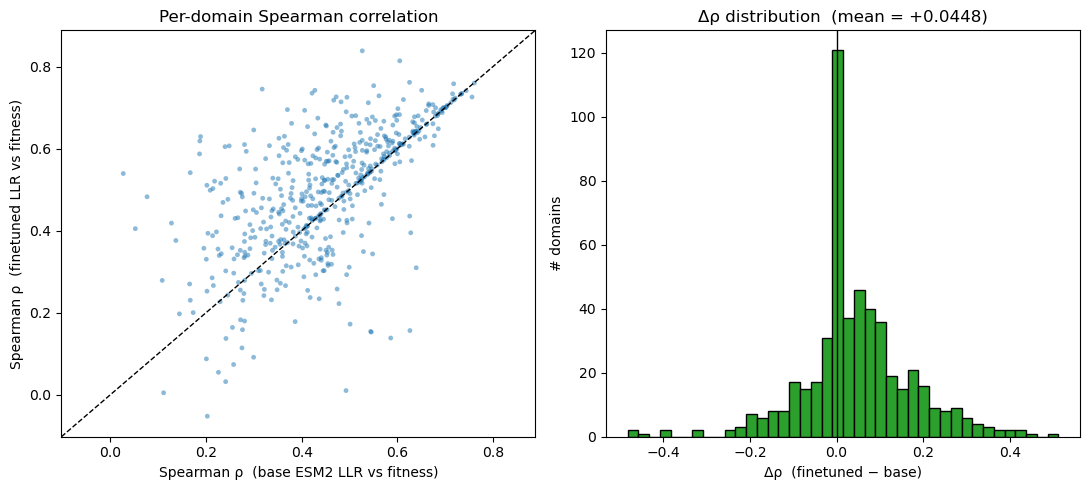

In [ ]:
# ── Plot: per-domain Spearman, base vs finetuned ─────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

lo = float(min(corr_df["rho_base"].min(), corr_df["rho_ft"].min())) - 0.05
hi = float(max(corr_df["rho_base"].max(), corr_df["rho_ft"].max())) + 0.05

axes[0].scatter(corr_df["rho_base"], corr_df["rho_ft"],
                alpha=0.5, s=12, edgecolor="none")
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
axes[0].set_xlabel("Spearman ρ  (base ESM2 LLR vs fitness)")
axes[0].set_ylabel("Spearman ρ  (finetuned LLR vs fitness)")
axes[0].set_title("Per-domain Spearman correlation")

axes[1].hist(corr_df["delta_rho"], bins=40, color="C2", edgecolor="black")
axes[1].axvline(0, color="k", linewidth=1)
axes[1].set_xlabel("Δρ  (finetuned − base)")
axes[1].set_ylabel("# domains")
axes[1].set_title(f"Δρ distribution  (mean = {corr_df['delta_rho'].mean():+.4f})")

plt.tight_layout()
plt.show()